#### Importation des bibliothèques

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
print("Bibliothèques importées avec succès.")


Bibliothèques importées avec succès.


#### Chargement du modèle

In [10]:
import os

print(os.path.exists(
    r"C:\Users\LENOVO\Documents\Soutenance\Project_soutenance\models\meilleur_modele.pkl"
))

True


In [4]:
modele = joblib.load("../models/meilleur_modele.pkl")

print("Meilleur modèle chargé.")

FileNotFoundError: [Errno 2] No such file or directory: '../models/meilleur_modele.pkl'

#### Chargement des données

In [5]:
data = pd.read_excel(
"C:/Users/LENOVO/Documents/Soutenance/Project_soutenance/data/processed/orbit_dataset_engineering.xlsx"
)

print(data.shape)

data.head()

(116720, 51)


,id_point,date_collecte,latitude,longitude,fillRate,fillRate_t_minus_1,fillRate_t_minus_2,delta_fillRate_24h,rolling_mean_3d,fillRate_target_t_plus_1,...,quartier_14,rendement_remplissage,pression_citoyenne,ratio_plaintes,indice_meteo,pression_collecte,charge_precollecteur,indice_saturation,indice_priorite,risque_debordement
0,0,2022-01-03,4.001501,9.73807,49.55,33.98,12.98,15.58,32.17,6.00,...,False,133.328571,0,0.0,1714.44,99.10,16.516667,908846.10,0.0,1594.0235
1,0,2022-01-04,4.001501,9.73807,6.00,49.55,33.98,-43.56,29.84,21.43,...,False,15.371429,0,0.0,2052.27,0.00,3.000000,110052.00,0.0,179.0400
2,0,2022-01-05,4.001501,9.73807,21.43,6.00,49.55,15.43,25.66,36.56,...,False,55.434286,0,0.0,1916.20,21.43,10.715000,393069.06,0.0,549.8938
3,0,2022-01-06,4.001501,9.73807,36.56,21.43,6.00,15.13,21.33,52.21,...,False,96.278571,0,0.0,2138.16,73.12,9.140000,670583.52,0.0,779.8248
4,0,2022-01-07,4.001501,9.73807,52.21,36.56,21.43,15.65,36.73,72.72,...,False,139.950000,0,0.0,1740.92,156.63,13.052500,957635.82,0.0,1917.6733


#### Variable cible

In [6]:
y = data["fillRate_target_t_plus_1"]

print(y.shape)

(116720,)


#### Variables explicatives

In [7]:
X = data.drop(
    columns=[
        "id_point",
        "date_collecte",
        "fillRate_target_t_plus_1"
    ]
)

print(X.shape)

(116720, 48)


#### Prédictions

In [8]:
predictions = modele.predict(X)

print(predictions[:10])

NameError: name 'modele' is not defined

#### Evaluation finale

In [6]:

mae = mean_absolute_error(y, predictions)

rmse = np.sqrt(mean_squared_error(y, predictions))

mape = mean_absolute_percentage_error(y, predictions)

r2 = r2_score(y, predictions)

print("MAE :", round(mae,3))

print("RMSE :", round(rmse,3))

print("MAPE :", round(mape,3))

print("R² :", round(r2,3))

MAE : 6.009
RMSE : 7.744
MAPE : 0.646
R² : 0.823


#### Importance des variables

In [11]:
results = pd.read_excel(
    "C:/Users/LENOVO/Documents/Soutenance/Project_soutenance/results/comparaison_modeles.xlsx"
)

print(results)

              Modele       MAE      RMSE      MAPE        R2  \
0  Gradient Boosting  6.311119  8.056672  0.675265  0.775217   
1           LightGBM  6.242009  8.056757  0.672624  0.775212   
2           CatBoost  6.242236  8.085187  0.676979  0.773623   
3      Random Forest  6.304479  8.100405  0.672121  0.772770   
4            XGBoost  6.396908  8.285991  0.672407  0.762239   
5  Linear Regression  7.911781  9.448654  0.740071  0.690834   

   Temps_Entrainement  Temps_Prediction  
0           83.253300          0.108374  
1            1.247756          0.041546  
2           23.463049          0.025626  
3          256.067512          0.487854  
4            1.569111          0.037841  
5            0.292571          0.013320  


#### Calcul de l'importance des variables

#### Importance des variables et leurs importances

In [13]:
importance = pd.DataFrame({
    "Variable": X.columns,
    "Importance": modele.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Variable,Importance
19,statut_prevu,0.616785
20,priorite_recommandee,0.226115
2,fillRate,0.112320
44,charge_precollecteur,0.023816
47,risque_debordement,0.005171
14,jour_semaine_num,0.003370
39,rendement_remplissage,0.002934
5,delta_fillRate_24h,0.002860
0,latitude,0.000967
15,is_weekend,0.000851



#### Que fait ce code ?
#### X.columns : récupère le nom de toutes les variables utilisées pour entraîner le modèle.
#### modele.feature_importances_ : récupère le score d'importance calculé par Gradient Boosting.
#### sort_values() : classe les variables de la plus importante à la moins importante.

#### Afficher les 15 variables les plus importantes

In [14]:
top15 = importance.head(15)

print(top15)

                      Variable  Importance
19                statut_prevu    0.616785
20        priorite_recommandee    0.226115
2                     fillRate    0.112320
44        charge_precollecteur    0.023816
47          risque_debordement    0.005171
14            jour_semaine_num    0.003370
39       rendement_remplissage    0.002934
5           delta_fillRate_24h    0.002860
0                     latitude    0.000967
15                  is_weekend    0.000851
1                    longitude    0.000747
11                 capacity_m3    0.000635
43           pression_collecte    0.000632
13  densite_population_hab_km2    0.000592
45           indice_saturation    0.000501


#### Visualisation

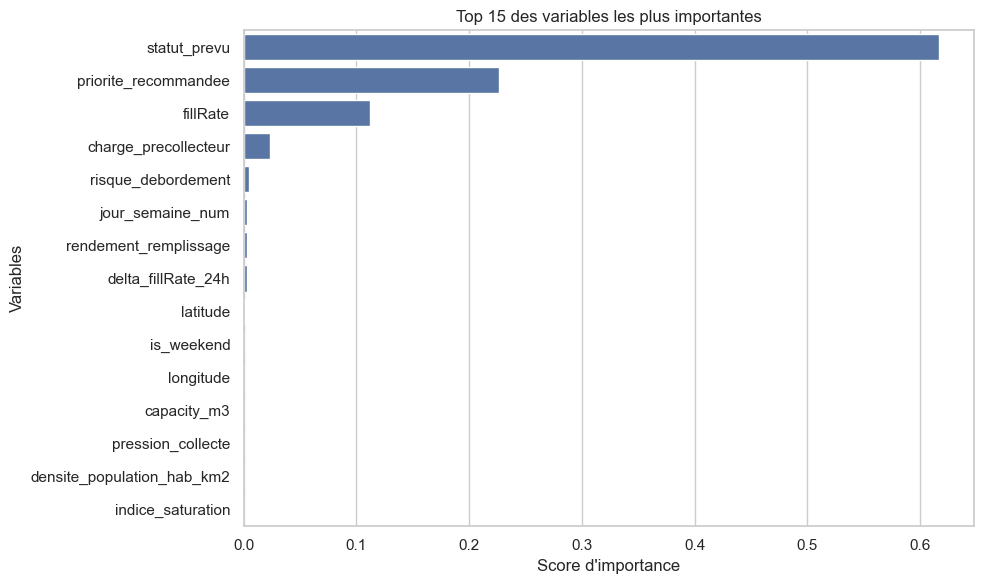

In [27]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top15,
    x="Importance",
    y="Variable"
)

plt.title("Top 15 des variables les plus importantes")

plt.xlabel("Score d'importance")

plt.ylabel("Variables")

plt.tight_layout()

plt.show()

#### Sauvegarde

In [16]:
importance.to_excel(
    "C:/Users/LENOVO/Documents/Soutenance/Project_soutenance/results/importance_variables.xlsx",
    index=False
)

print("Importance des variables enregistrée.")

Importance des variables enregistrée.


#### Création du tableau

In [17]:
comparaison = pd.DataFrame({

    "Valeur_reelle": y,

    "Prediction": predictions

})

comparaison.head(10)

,Valeur_reelle,Prediction
0,6.00,9.600721
1,21.43,17.379470
2,36.56,24.739989
3,52.21,50.579721
4,72.72,73.755757
5,14.71,9.987804
6,30.54,21.483518
7,10.78,21.292243
8,5.05,19.026924
9,20.03,14.010171


#### Graphique

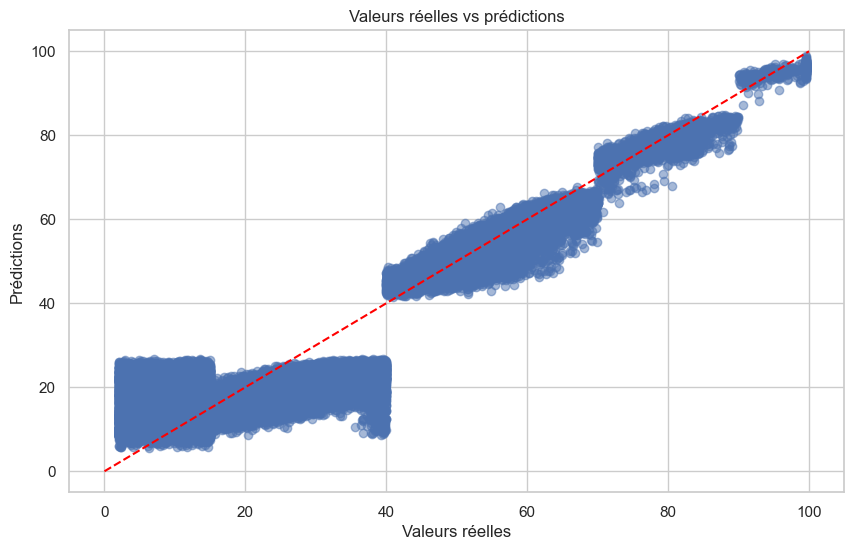

In [18]:

plt.figure(figsize=(10,6))

plt.scatter(
    comparaison["Valeur_reelle"],
    comparaison["Prediction"],
    alpha=0.5
)

plt.plot(
    [0,100],
    [0,100],
    color="red",
    linestyle="--"
)

plt.xlabel("Valeurs réelles")

plt.ylabel("Prédictions")

plt.title("Valeurs réelles vs prédictions")

plt.show()

#### Interprétation: Les points proches de la diagonale représentent des prédictions précises. 
    
#### Plus les observations sont concentrées autour de cette ligne, plus le modèle reproduit fidèlement les valeurs réelles du taux de remplissage.


#### Analyse des résidus

In [19]:
comparaison["Residus"] = (
    comparaison["Valeur_reelle"]
    -
    comparaison["Prediction"]
)

comparaison.head()

,Valeur_reelle,Prediction,Residus
0,6.00,9.600721,-3.600721
1,21.43,17.379470,4.050530
2,36.56,24.739989,11.820011
3,52.21,50.579721,1.630279
4,72.72,73.755757,-1.035757


#### Histogramme

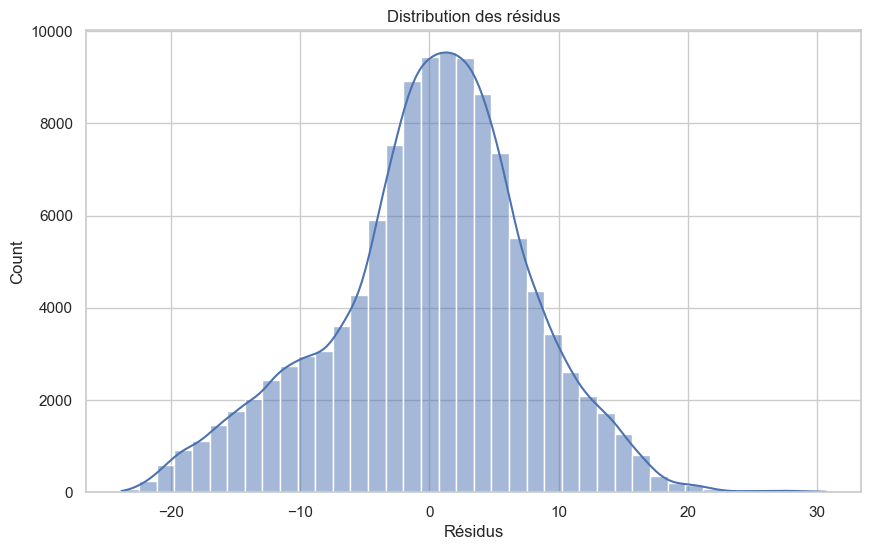

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(
    comparaison["Residus"],
    bins=40,
    kde=True
)

plt.title("Distribution des résidus")

plt.xlabel("Résidus")

plt.show()

#### Résidus vs prédictions

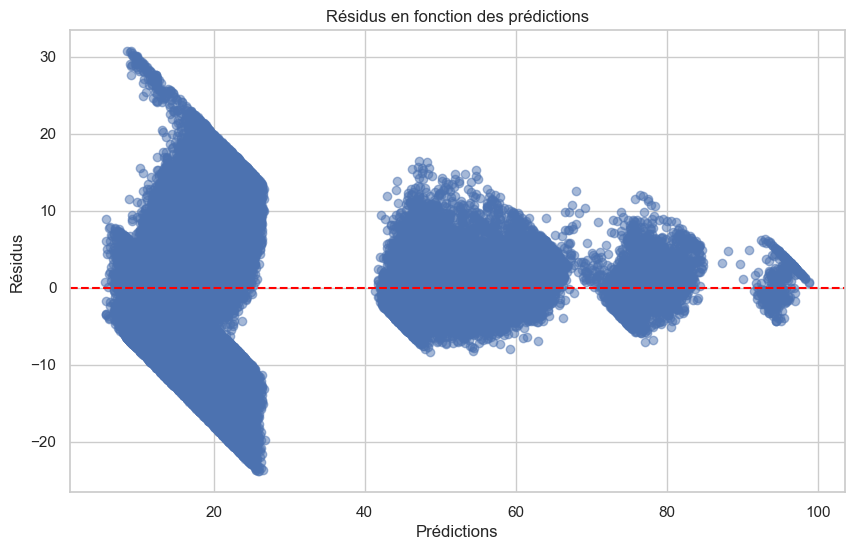

In [22]:

plt.figure(figsize=(10,6))

plt.scatter(
    comparaison["Prediction"],
    comparaison["Residus"],
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Prédictions")

plt.ylabel("Résidus")

plt.title("Résidus en fonction des prédictions")

plt.show()

#### Interprétation:  Une répartition aléatoire des résidus autour de zéro indique que le modèle ne présente pas de biais systématique 

#### et que les erreurs de prédiction restent globalement équilibrées.